# Importation des modules

In [1]:
!pip install openpyxl
!pip install missingno
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 92.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 91.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [missingno]10 [seaborn]ib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 32.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [2]:
import pandas as pd
import numpy as np
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Chargement des données
diviser les dépenses de santé par le PIB pour les avoir en %  
rajouter les données de dépenses de santé pour 1994 - 2004 en regardant sur les données de l'ocde  
rajouter la base mortalite  
faire le tri dans les pays de la bdd nb de médecins  


In [3]:
depenses_sante_vol = pd.read_excel(os.path.join("data", "Depenses_sante_en_volume_fr.xlsx"))
depenses_sante_PIB = pd.read_excel(os.path.join("data", "Depenses_Sante_PIB_OCDE_fr.xlsx"))
pib = pd.read_excel(os.path.join("data", "PIB_fr.xlsx"))
pib_par_habitant = pd.read_excel(os.path.join("data", "PIB_par_habitant_fr.xlsx"))
pop_tot = pd.read_excel(os.path.join("data", "Pop_tot_fr.xlsx"))
pop65 = pd.read_excel(os.path.join("data", "Pop+65ans_fr.xlsx"))
part_pop65 = pd.read_excel(os.path.join("data", "part_pop_plus_65_fr.xlsx"))
pop_par_age = pd.read_excel(os.path.join("data", "Population_par_age_tranches5ans_fr.xlsx"))
active_physicians = pd.read_excel(os.path.join("data", "active_physicians.xlsx"))
hospital_beds = pd.read_excel(os.path.join("data", "hospital_beds.xlsx"))
taux_deces_2ans = pd.read_excel('data/Taux_Deces_2ans.xlsx', index_col=None)
taux_deces_2ans = taux_deces_2ans.rename(columns={taux_deces_2ans.columns[0]: 'TIME'})
chom=pd.read_excel(os.path.join("data", "taux_chomage_panel.xlsx"))

In [4]:
hospital_beds

,TIME,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Autriche,7.69,7.66,7.75,7.69,7.68,7.65,7.68,7.67,7.64,7.58,7.54,7.42,7.37,7.27,7.19,7.05,6.91,6.72,NaN
1,Belgique,6.02,5.98,5.93,5.89,5.83,5.75,5.69,5.64,5.61,5.63,5.69,5.64,5.55,5.52,5.47,5.44,5.41,5.35,5.30
2,Tchéquie,6.37,6.30,6.18,6.09,6.03,5.94,5.75,5.60,5.40,5.36,5.39,5.70,5.71,5.68,5.67,5.86,5.93,4.92,4.83
3,Danemark,3.86,3.79,3.69,3.57,3.49,3.50,3.13,NaN,3.07,2.69,2.53,2.60,2.61,2.61,2.59,2.59,2.51,NaN,NaN
4,Estonie,5.38,5.55,5.48,5.63,5.37,5.27,5.36,5.53,5.01,5.01,4.96,4.76,4.69,4.57,4.63,4.57,4.48,4.39,4.17
5,Finlande,7.05,6.99,6.73,6.57,6.25,5.85,5.52,5.30,4.87,4.53,4.35,3.97,3.28,3.21,3.30,2.83,2.76,NaN,NaN
6,France,7.22,7.11,7.06,6.90,6.66,6.43,6.36,6.34,6.27,6.20,6.13,6.06,5.98,5.89,5.83,5.72,NaN,NaN,NaN
7,Allemagne,6.26,6.13,5.57,6.10,6.11,6.20,6.24,6.22,6.20,6.17,6.11,6.06,6.01,5.96,6.00,5.87,5.81,5.78,NaN
8,Grèce,4.78,4.87,4.88,4.84,4.93,4.48,4.47,4.45,4.24,4.24,4.25,4.20,4.21,4.20,4.18,4.23,4.27,4.26,4.24
9,Hongrie,7.89,7.93,7.15,7.07,7.09,7.12,7.15,6.94,7.01,6.99,7.00,7.00,7.02,7.02,6.99,6.98,6.92,6.82,6.62


# Construction du Time-to-Death

In [4]:
def time_to_death(mortalite, pop) :
    # pour pop, à voir si on prend pop_tot, pop_65 ou une population plus âgée encore
    # ou faire une somme pondérée des mortalités pour les 65-70, 70-75, etc
    # fait par chatgpt, à revoir en fonction de la structure des données
    df = mortalite.merge(
        pop_tot,
        on=["country", "year", "age"],
        how="inner"
    )

    df["weighted_mortality"] = df["mortality_rate"] * df["population"]
    ttd = (
        df.groupby(["country", "year"])["weighted_mortality"]
          .sum()
          .reset_index(name="TTD")
    )
    return ttd

#pop = pop_65   # ou pop_80, ou pop_tot...
#ttd = time_to_death(mortalite, pop)

# Mise en forme du panel

In [5]:
def preparer_donnees(fichier, var) :   #var est un str indiquant le nom de la variable, comme "PIB" ou "depenses"
    df = fichier.copy()
    df = df.replace(':', np.nan)
    df = pd.melt(df, id_vars=['TIME'], var_name='Year', value_name=var)
    df = df.rename(columns={'TIME': 'Country'})
    df['Year'] = df['Year'].astype(int)  # S'assurer que l'année est un entier
    df = df.set_index(['Country', 'Year']).sort_index()
    return df

In [30]:
panel_depenses_sante_PIB = preparer_donnees(depenses_sante_PIB, "Depenses de sante en % du PIB")
panel_PIB_par_habitant = preparer_donnees(pib_par_habitant, "PIB par habitant")
#panel_PIB = preparer_donnees(pib, "PIB")
panel_chom=preparer_donnees(chom, "Chomage")
panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
#panel = pd.merge(panel_depenses_sante_PIB, panel_PIB, on=['Country', 'Year'], how='outer')
panel_pop65 = preparer_donnees(part_pop65, "Part des +65 ans")
panel = pd.merge(panel, panel_pop65, on=['Country', 'Year'], how='outer')
panel_active_physicians = preparer_donnees(active_physicians, "Practiciens pour 1000 habitants")
panel = pd.merge(panel, panel_active_physicians, on=['Country', 'Year'], how='outer')
panel_hospital_beds = preparer_donnees(hospital_beds, "Lits d hopitaux pour 1000 habitants")
panel = pd.merge(panel, panel_hospital_beds, on=['Country', 'Year'], how='outer')
panel_taux_deces_2ans = preparer_donnees(taux_deces_2ans, "Taux deces 2 ans")
panel = pd.merge(panel, panel_taux_deces_2ans, on=['Country', 'Year'], how='outer')
panel = pd.merge(panel, panel_chom, on=['Country', 'Year'], how='outer')
panel['Depenses t-1'] = panel.groupby(level='Country')['Depenses de sante en % du PIB'].shift(1)


# 3. Structuration en Panel (MultiIndex)
#panel = panel.set_index(['Country', 'Year']).sort_index()
panel.loc['Portugal']

,Depenses de sante en % du PIB,PIB par habitant,Part des +65 ans,Practiciens pour 1000 habitants,Lits d hopitaux pour 1000 habitants,Taux deces 2 ans,Chomage,Depenses t-1
Year,,,,,,,,
1993,NaN,NaN,0.142398,NaN,NaN,NaN,NaN,NaN
1994,NaN,NaN,0.145039,NaN,NaN,NaN,NaN,NaN
1995,NaN,60.9,0.147758,NaN,NaN,NaN,NaN,NaN
1996,NaN,61.6,0.150645,NaN,NaN,NaN,NaN,NaN
1997,NaN,63.8,0.153210,NaN,NaN,NaN,NaN,NaN
1998,NaN,65.4,0.155996,NaN,NaN,NaN,NaN,NaN
1999,NaN,67.2,0.158368,NaN,NaN,NaN,NaN,NaN
2000,NaN,67.8,0.160296,NaN,NaN,NaN,NaN,NaN
2001,NaN,68.0,0.163408,NaN,NaN,NaN,NaN,NaN


In [15]:
panel.head()

Depenses de sante en % du PIB        PIB  Part des +65 ans  \
Country   Year                                                               
Allemagne 1993                            NaN  1774986.2          0.150370   
          1994                            NaN  1867918.1          0.151962   
          1995                            NaN  1983157.1          0.153814   
          1996                            NaN  1975310.3          0.155620   
          1997                            NaN  1958621.6          0.156767   

                Practiciens pour 1000 habitants  \
Country   Year                                    
Allemagne 1993                              NaN   
          1994                              NaN   
          1995                              NaN   
          1996                              NaN   
          1997                              NaN   

                Lits d hopitaux pour 1000 habitants  Taux deces 2 ans  \
Country   Year                                                          
Allemagne 1993                                  NaN               NaN   
          1994                                  NaN               NaN   
          1995                                  NaN               NaN   
          1996                                  NaN               NaN   
          1997                                  NaN               NaN   

                Chomage  Depenses t-1  
Country   Year                         
Allemagne 1993      NaN           NaN  
          1994      NaN           NaN  
          1995      NaN           NaN  
          1996      NaN           NaN  
          1997      NaN           NaN

In [32]:
annees_a_supprimer = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2024, 2025]
panel = panel.drop(annees_a_supprimer, level='Year')
panel = panel.drop("Suède", level='Country')
#panel = panel.drop("UK", level='Country')
panel

Depenses de sante en % du PIB  PIB par habitant  \
Country   Year                                                    
Allemagne 2005                         10.107             129.3   
          2006                          9.962             128.1   
          2007                          9.835             127.2   
          2008                         10.032             126.3   
          2009                         10.970             127.9   
...                                       ...               ...   
Tchéquie  2019                          7.488              68.6   
          2020                          8.970              68.8   
          2021                          9.154              70.4   
          2022                          8.471              73.8   
          2023                          8.427              76.4   

                Part des +65 ans  Practiciens pour 1000 habitants  \
Country   Year                                                      
Allemagne 2005          0.186270                             3.40   
          2006          0.192509                             3.44   
          2007          0.198011                             3.49   
          2008          0.200914                             3.54   
          2009          0.204006                             3.62   
...                          ...                              ...   
Tchéquie  2019          0.195930                             4.07   
          2020          0.199331                             4.13   
          2021          0.205037                             4.26   
          2022          0.206254                             4.32   
          2023          0.203911                             4.86   

                Lits d hopitaux pour 1000 habitants  Taux deces 2 ans  \
Country   Year                                                          
Allemagne 2005                                 6.26             2.002   
          2006                                 6.13             2.000   
          2007                                 5.57             2.031   
          2008                                 6.10             2.066   
          2009                                 6.11             2.089   
...                                             ...               ...   
Tchéquie  2019                                 5.67             2.269   
          2020                                 5.86             2.517   
          2021                                 5.93             2.478   
          2022                                 4.92             2.216   
          2023                                 4.83               NaN   

                Chomage  Depenses t-1  
Country   Year                         
Allemagne 2005     11.2         9.975  
          2006     10.3        10.107  
          2007      8.7         9.962  
          2008      7.5         9.835  
          2009      7.8        10.032  
...                 ...           ...  
Tchéquie  2019      2.0         7.372  
          2020      2.6         7.488  
          2021      2.8         8.970  
          2022      2.2         9.154  
          2023      2.6         8.471  

[380 rows x 8 columns]

In [22]:
panel.loc[panel['Practiciens pour 1000 habitants'].isna()]

Depenses de sante en % du PIB        PIB  Part des +65 ans  \
Country    Year                                                               
Allemagne  2023                         11.744    4219310          0.222456   
Autriche   2023                         11.153   477837.3          0.195579   
Danemark   2022                          9.474   380567.4          0.203496   
           2023                          9.513   374173.6          0.204517   
Finlande   2022                          9.742     266135          0.230530   
           2023                         10.474     273005          0.232660   
France     2023                         11.503  2826541.5          0.211297   
Irlande    2005                          7.642   170306.8          0.111046   
           2006                          7.516   184916.2          0.109666   
           2007                          7.808   197069.4          0.108029   
           2008                          9.126   187283.0          0.107764   
           2009                         10.523   169519.7          0.109440   
           2010                         10.521   167255.1          0.112171   
Italie     2023                          8.406  2142601.7          0.240372   
Luxembourg 2018                          5.274    60193.4          0.143201   
           2019                          5.466    62415.0          0.143882   
           2020                          5.767    64499.2          0.145002   
           2021                          5.608    73039.5          0.146105   
           2022                          5.609    76731.2          0.147505   
           2023                          5.668    82115.5          0.148636   
Portugal   2023                         10.028   270352.6          0.238756   

                 Practiciens pour 1000 habitants  \
Country    Year                                    
Allemagne  2023                              NaN   
Autriche   2023                              NaN   
Danemark   2022                              NaN   
           2023                              NaN   
Finlande   2022                              NaN   
           2023                              NaN   
France     2023                              NaN   
Irlande    2005                              NaN   
           2006                              NaN   
           2007                              NaN   
           2008                              NaN   
           2009                              NaN   
           2010                              NaN   
Italie     2023                              NaN   
Luxembourg 2018                              NaN   
           2019                              NaN   
           2020                              NaN   
           2021                              NaN   
           2022                              NaN   
           2023                              NaN   
Portugal   2023                              NaN   

                 Lits d hopitaux pour 1000 habitants  Taux deces 2 ans  \
Country    Year                                                          
Allemagne  2023                                  NaN               NaN   
Autriche   2023                                  NaN             1.958   
Danemark   2022                                  NaN             2.006   
           2023                                  NaN               NaN   
Finlande   2022                                  NaN             2.245   
           2023                                  NaN               NaN   
France     2023                                  NaN               NaN   
Irlande    2005                                 5.52             1.380   
           2006                                 5.34             1.345   
           2007                                 5.17             1.299   
           2008                                 4.89             1.271   
           2009                         

In [23]:
panel.loc[panel['Lits d hopitaux pour 1000 habitants'].isna()]

Depenses de sante en % du PIB        PIB  Part des +65 ans  \
Country    Year                                                               
Allemagne  2023                         11.744    4219310          0.222456   
Autriche   2023                         11.153   477837.3          0.195579   
Danemark   2012                         10.517   254300.7          0.173476   
           2022                          9.474   380567.4          0.203496   
           2023                          9.513   374173.6          0.204517   
Finlande   2022                          9.742     266135          0.230530   
           2023                         10.474     273005          0.232660   
France     2021                         12.249  2508102.3          0.206266   
           2022                         11.835  2653997.2          0.208694   
           2023                         11.503  2826541.5          0.211297   
Lettonie   2023                          7.278    39564.2          0.209727   
Luxembourg 2021                          5.608    73039.5          0.146105   
           2022                          5.609    76731.2          0.147505   
           2023                          5.668    82115.5          0.148636   
Portugal   2023                         10.028   270352.6          0.238756   

                 Practiciens pour 1000 habitants  \
Country    Year                                    
Allemagne  2023                              NaN   
Autriche   2023                              NaN   
Danemark   2012                             3.84   
           2022                              NaN   
           2023                              NaN   
Finlande   2022                              NaN   
           2023                              NaN   
France     2021                             3.18   
           2022                             3.19   
           2023                              NaN   
Lettonie   2023                             3.36   
Luxembourg 2021                              NaN   
           2022                              NaN   
           2023                              NaN   
Portugal   2023                              NaN   

                 Lits d hopitaux pour 1000 habitants  Taux deces 2 ans  \
Country    Year                                                          
Allemagne  2023                                  NaN               NaN   
Autriche   2023                                  NaN             1.958   
Danemark   2012                                  NaN             1.878   
           2022                                  NaN             2.006   
           2023                                  NaN               NaN   
Finlande   2022                                  NaN             2.245   
           2023                                  NaN               NaN   
France     2021                                  NaN             1.974   
           2022                                  NaN             1.931   
           2023                                  NaN               NaN   
Lettonie   2023                                  NaN               NaN   
Luxembourg 2021                                  NaN             1.408   
           2022                                  NaN             1.376   
           2023                                  NaN               NaN   
Portugal   2023                                  NaN             2.250   

                 Chomage  Depenses t-1  
Country    Year                         
Allemagne  2023      3.1        12.447  
Autriche   2023      5.1        11.225  
Danemark   2012      7.8        10.378  
           2022      4.5        10.656  
           2023      5.1         9.474  
Finlande   2022      6.8         9.910  
           2023      7.2         9.742  
France     2021      7.9        12.129  
           2022      7.3        12.249  
           2023      7.3        11.835  
Lettonie   2023      6.5         8.10

## Visualisation des valeurs manquantes

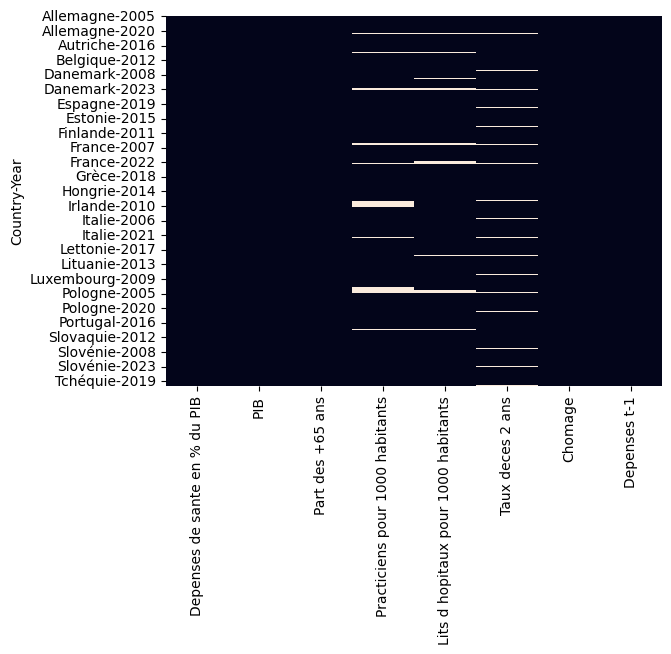

In [24]:
df = panel.copy()
sns.heatmap(df.isna(), cbar=False)
plt.show()

<Axes: >

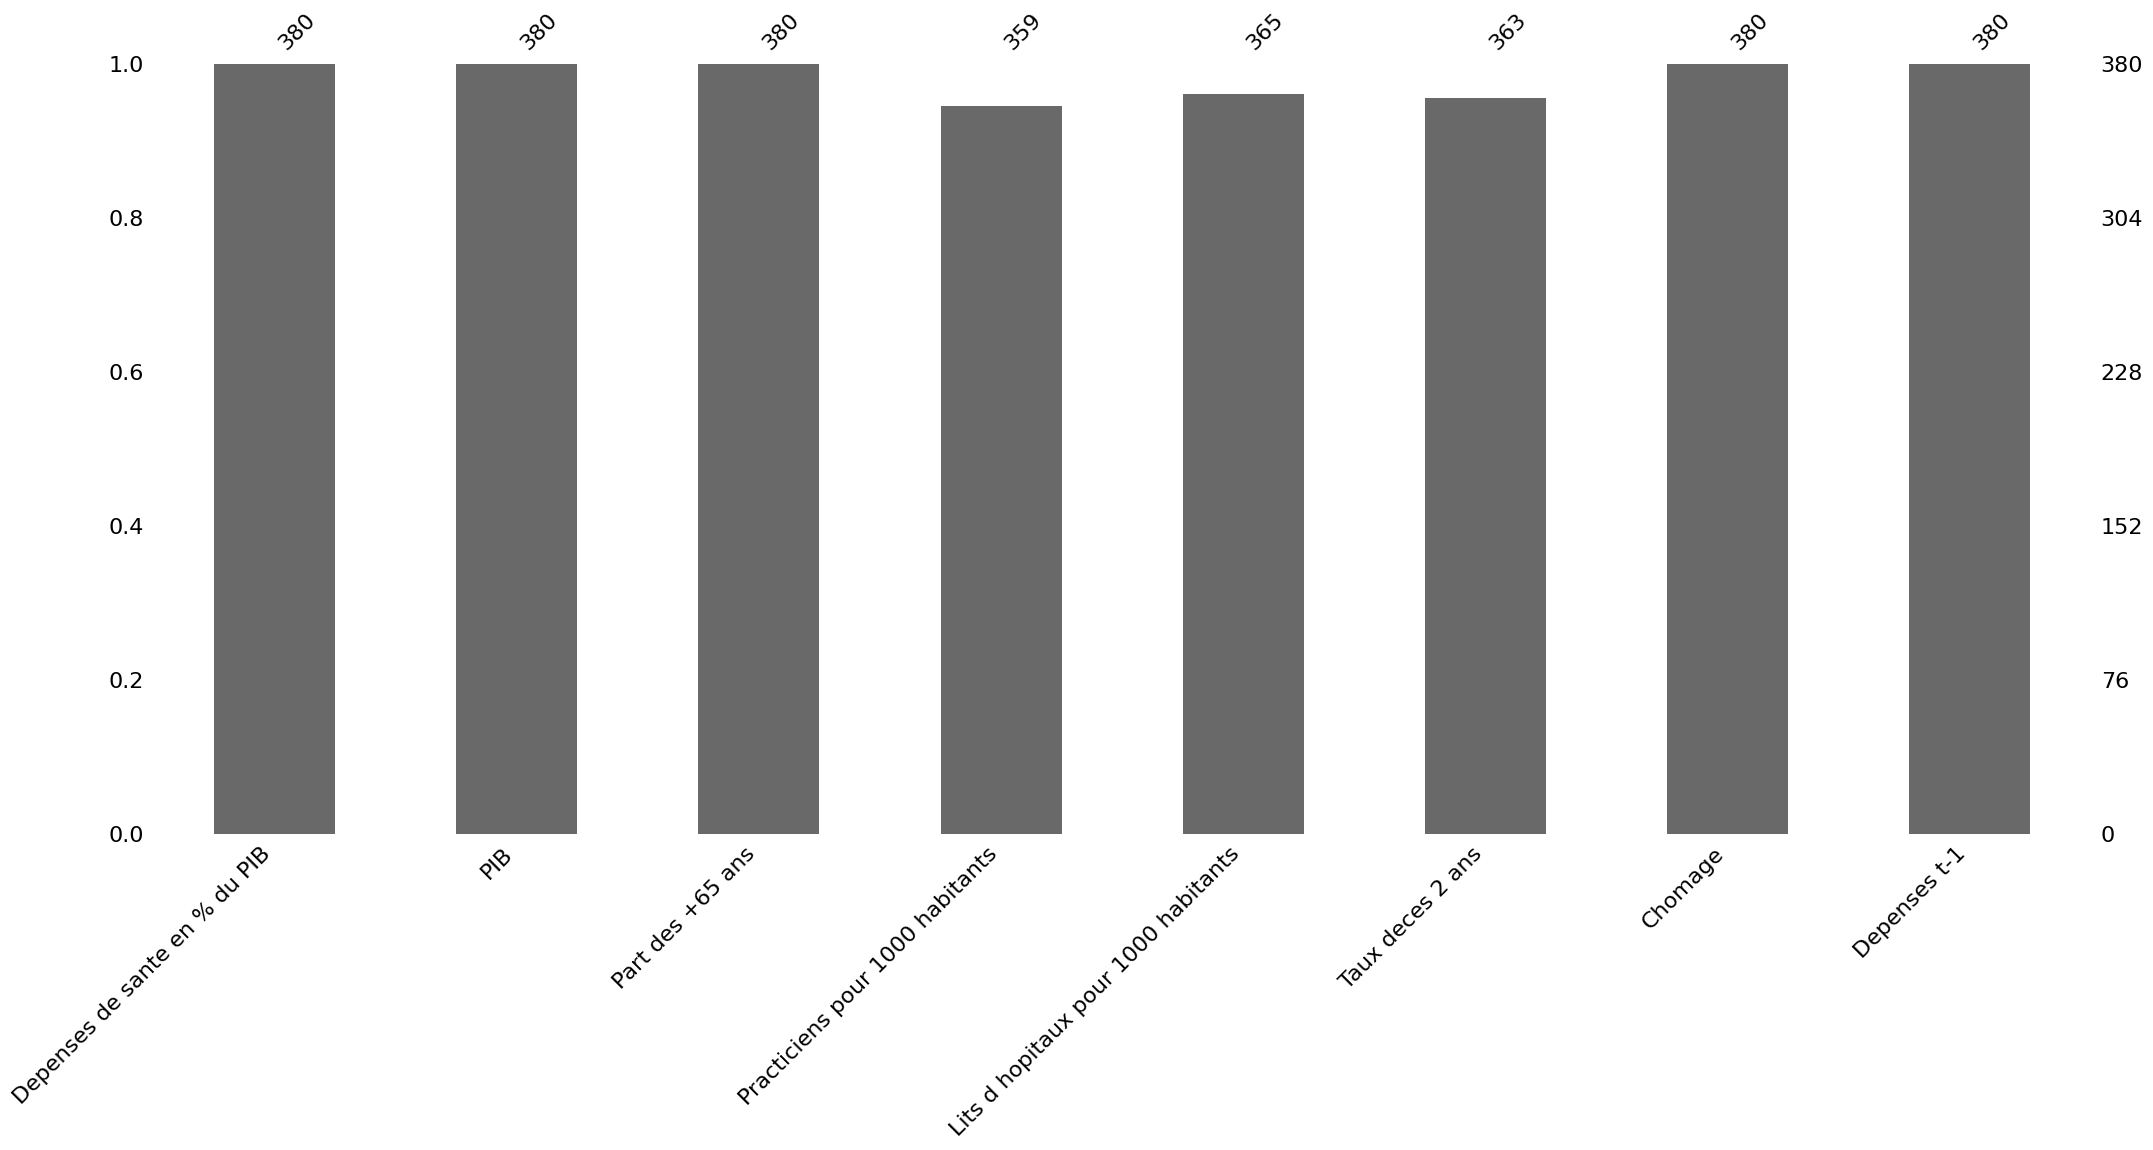

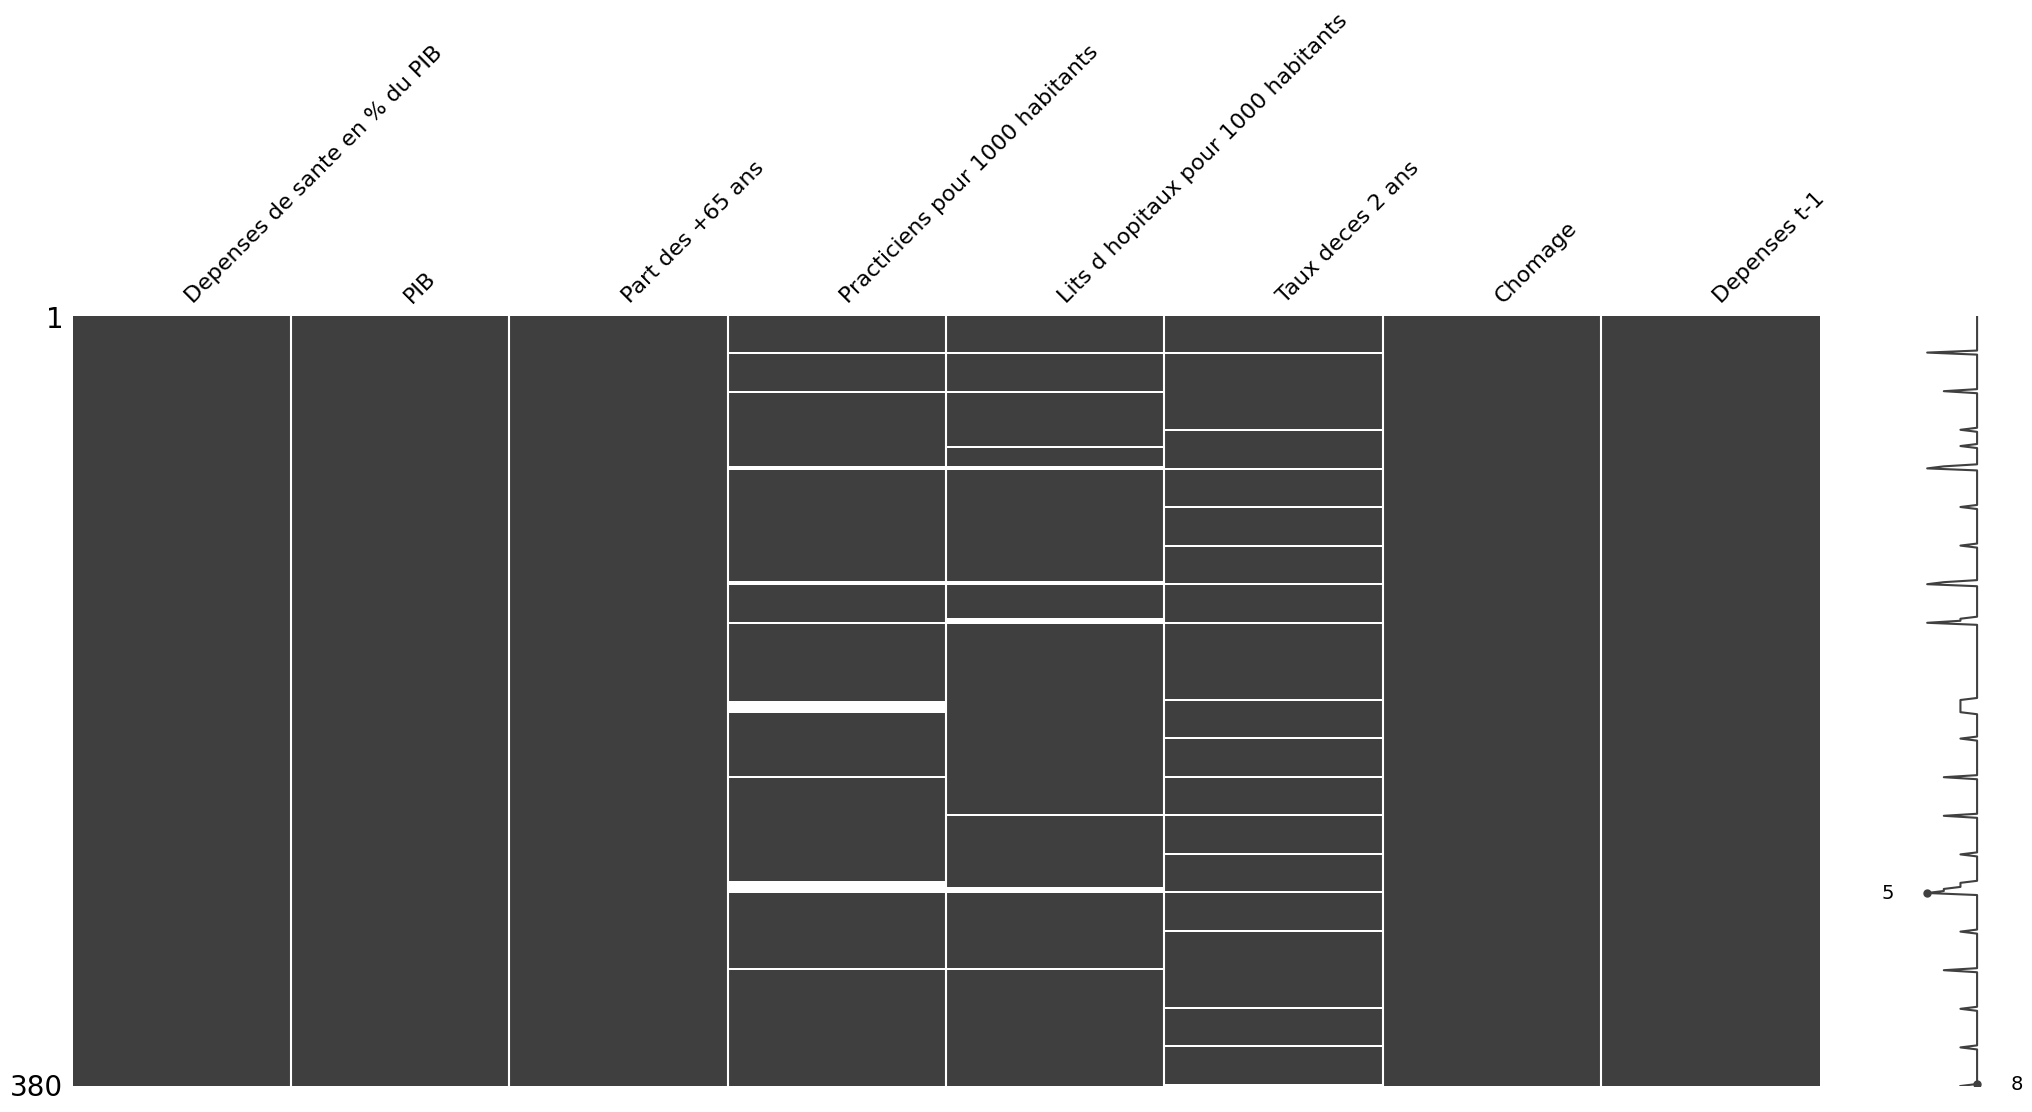

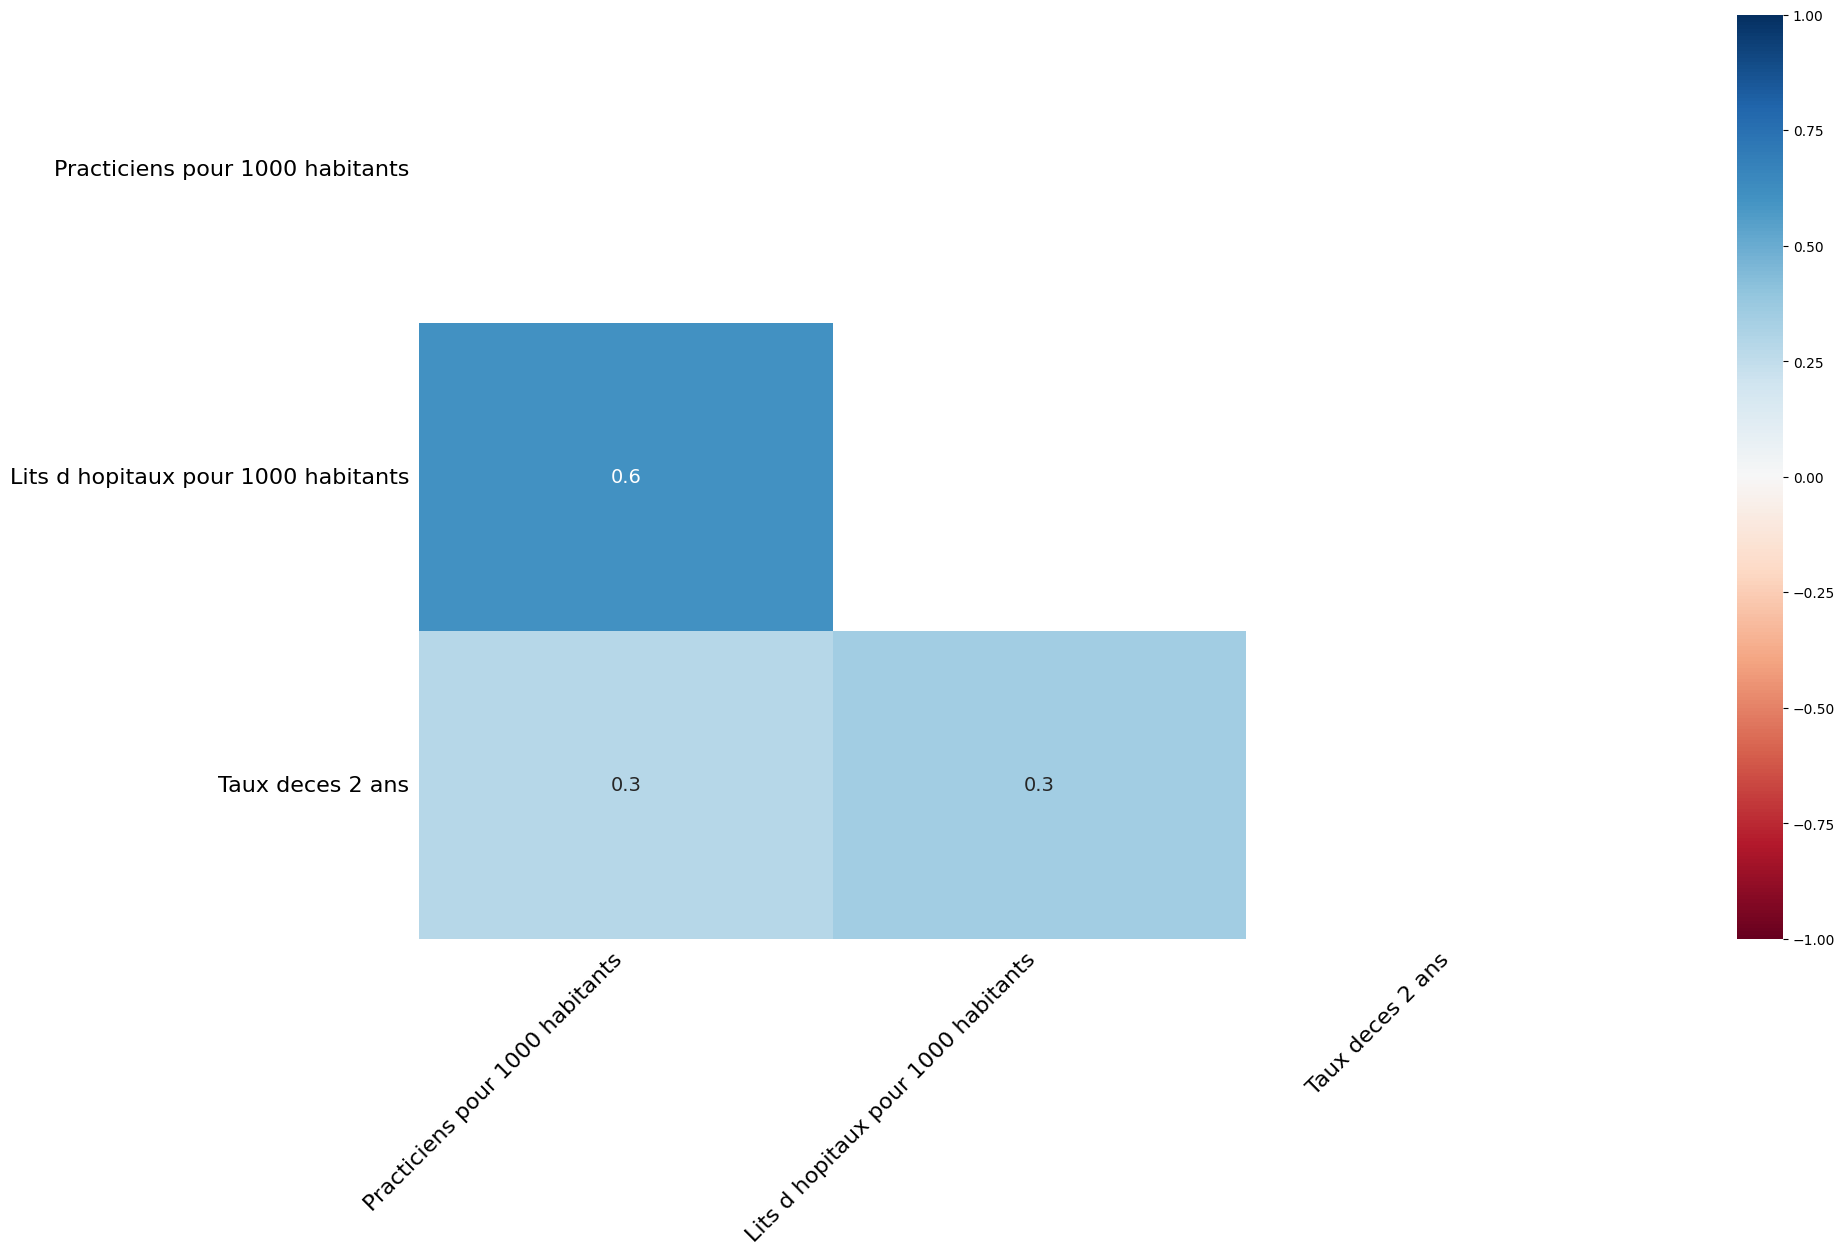

In [25]:
#visualisation des valeurs manquantes

df = panel.copy()
msno.bar(df)
msno.matrix(df)
msno.heatmap(df)

A value near -1 means if one variable appears then the other variable is very likely to be missing.  
A value near 0 means there is no dependence between the occurrence of missing values of two variables.  
A value near 1 means if one variable appears then the other variable is very likely to be present.  

In [26]:
missing_indicator = df.isna().astype(int)
corr = missing_indicator.corr()

print(corr)

                                     Depenses de sante en % du PIB  PIB  \
Depenses de sante en % du PIB                                  NaN  NaN   
PIB                                                            NaN  NaN   
Part des +65 ans                                               NaN  NaN   
Practiciens pour 1000 habitants                                NaN  NaN   
Lits d hopitaux pour 1000 habitants                            NaN  NaN   
Taux deces 2 ans                                               NaN  NaN   
Chomage                                                        NaN  NaN   
Depenses t-1                                                   NaN  NaN   

                                     Part des +65 ans  \
Depenses de sante en % du PIB                     NaN   
PIB                                               NaN   
Part des +65 ans                                  NaN   
Practiciens pour 1000 habitants                   NaN   
Lits d hopitaux pour 1000 habitants    

## Données manquantes

In [34]:
panel.columns

Index(['Depenses de sante en % du PIB', 'PIB par habitant', 'Part des +65 ans',
       'Practiciens pour 1000 habitants',
       'Lits d hopitaux pour 1000 habitants', 'Taux deces 2 ans', 'Chomage',
       'Depenses t-1'],
      dtype='str')

In [35]:
#gérer les données manquantes
panel_transformed = panel.copy()

for col in ['Depenses de sante en % du PIB', 'PIB par habitant', 'Part des +65 ans', 'Practiciens pour 1000 habitants',
       'Lits d hopitaux pour 1000 habitants', 'Taux deces 2 ans', 'Chomage'] :
    panel_transformed[col] = panel_transformed.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

In [36]:
panel_transformed

Depenses de sante en % du PIB  PIB par habitant  \
Country   Year                                                    
Allemagne 2005                         10.107             129.3   
          2006                          9.962             128.1   
          2007                          9.835             127.2   
          2008                         10.032             126.3   
          2009                         10.970             127.9   
...                                       ...               ...   
Tchéquie  2019                          7.488              68.6   
          2020                          8.970              68.8   
          2021                          9.154              70.4   
          2022                          8.471              73.8   
          2023                          8.427              76.4   

                Part des +65 ans  Practiciens pour 1000 habitants  \
Country   Year                                                      
Allemagne 2005          0.186270                             3.40   
          2006          0.192509                             3.44   
          2007          0.198011                             3.49   
          2008          0.200914                             3.54   
          2009          0.204006                             3.62   
...                          ...                              ...   
Tchéquie  2019          0.195930                             4.07   
          2020          0.199331                             4.13   
          2021          0.205037                             4.26   
          2022          0.206254                             4.32   
          2023          0.203911                             4.86   

                Lits d hopitaux pour 1000 habitants  Taux deces 2 ans  \
Country   Year                                                          
Allemagne 2005                                 6.26             2.002   
          2006                                 6.13             2.000   
          2007                                 5.57             2.031   
          2008                                 6.10             2.066   
          2009                                 6.11             2.089   
...                                             ...               ...   
Tchéquie  2019                                 5.67             2.269   
          2020                                 5.86             2.517   
          2021                                 5.93             2.478   
          2022                                 4.92             2.216   
          2023                                 4.83             2.073   

                Chomage  Depenses t-1  
Country   Year                         
Allemagne 2005     11.2         9.975  
          2006     10.3        10.107  
          2007      8.7         9.962  
          2008      7.5         9.835  
          2009      7.8        10.032  
...                 ...           ...  
Tchéquie  2019      2.0         7.372  
          2020      2.6         7.488  
          2021      2.8         8.970  
          2022      2.2         9.154  
          2023      2.6         8.471  

[380 rows x 8 columns]

In [38]:
panel.to_csv("panel.csv", index=False)
panel_transformed.to_csv("panelV2.csv", index=True)

# Régression TTD  
On veut vérifier si contrôler par le TTD atténue l'impact du vieillissement sur les dépenses de santé.  
On fait notre régression sur plusieurs tranches d'âge au-dessus de 65 ans. Comme TTD, on utilise l'espérance de vie résiduelle de la tranche d'âge sur laquelle on se place et on remplace

# Two Way fixed effects

In [17]:
print(panel.index.names)
print(panel.columns.tolist())


['Country', 'Year']
['Depenses de sante en % du PIB', 'PIB par habitant', 'Part des +65 ans', 'Practiciens pour 1000 habitants', 'Lits d hopitaux pour 1000 habitants', 'Taux deces 2 ans', 'Chomage', 'Depenses t-1']


In [18]:
import pandas as pd
import numpy as np
from scipy import stats

DEP     = 'Depenses de sante en % du PIB'
M1_REGS = ['Part des +65 ans', 'PIB par habitant', 'Chomage']
M2_REGS = ['Part des +65 ans', 'Taux deces 2 ans', 'PIB par habitant', 'Chomage']

def twfe(data, regressors, dep):
    cols = ['Country', 'Year', dep] + regressors
    sub  = data[cols].dropna().copy().sort_values(['Country', 'Year'])
    for col in [dep] + regressors:
        sub[col+'_fe'] = (sub[col]
                         - sub.groupby('Year')[col].transform('mean')
                         - sub.groupby('Country')[col].transform('mean')
                         + sub[col].mean())
    Y         = sub[dep+'_fe'].values
    X         = sub[[r+'_fe' for r in regressors]].values
    countries = sub['Country'].values
    N, k      = X.shape
    G         = len(np.unique(countries))

    beta  = np.linalg.lstsq(X, Y, rcond=None)[0]
    resid = Y - X @ beta

    meat = np.zeros((k, k))
    for c in np.unique(countries):
        idx = countries == c
        sc  = X[idx].T @ resid[idx]
        meat += np.outer(sc, sc)
    corr    = G/(G-1) * (N-1)/(N-k)
    XtX_inv = np.linalg.inv(X.T @ X)
    se      = np.sqrt(np.diag(corr * XtX_inv @ meat @ XtX_inv))
    t       = beta / se
    p       = 2 * (1 - stats.t.cdf(np.abs(t), df=G-1))
    r2      = 1 - np.sum(resid**2) / np.sum((Y - Y.mean())**2)

    return beta, se, t, p, r2, N

def sig(p):
    return "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))

# Reset index si Country/Year sont dans l'index
panel = panel.reset_index()

b1, se1, t1, p1, r2_1, n1 = twfe(panel, M1_REGS, DEP)
b2, se2, t2, p2, r2_2, n2 = twfe(panel, M2_REGS, DEP)

# Affichage
all_vars = ['Part des +65 ans', 'Taux deces 2 ans', 'PIB par habitant', 'Chomage']
labels   = ['Part des +65 ans', 'Taux de décès <2 ans', 'PIB par habitant', 'Taux de chômage']

print(f"\n{'='*65}")
print(f"  TWFE — Dépenses santé (% PIB)")
print(f"{'='*65}")
print(f"  {'Variable':<28} {'Modèle 1':>16} {'Modèle 2':>16}")
print(f"  {'-'*63}")

for var, lab in zip(all_vars, labels):
    c1 = f"{b1[M1_REGS.index(var)]:.4f} {sig(p1[M1_REGS.index(var)])}" if var in M1_REGS else "—"
    s1 = f"({se1[M1_REGS.index(var)]:.4f})" if var in M1_REGS else ""
    i2 = M2_REGS.index(var)
    c2, s2 = f"{b2[i2]:.4f} {sig(p2[i2])}", f"({se2[i2]:.4f})"
    print(f"  {lab:<28} {c1:>16} {c2:>16}")
    print(f"  {'':28} {s1:>16} {s2:>16}")

print(f"  {'-'*63}")
print(f"  {'FE pays + année':<28} {'Oui':>16} {'Oui':>16}")
print(f"  {'Observations':<28} {n1:>16} {n2:>16}")
print(f"  {'R² within':<28} {r2_1:>16.4f} {r2_2:>16.4f}")
print(f"{'='*65}")
print("  SE clustérisées par pays. * p<0.05  ** p<0.01  *** p<0.001")


  TWFE — Dépenses santé (% PIB)
  Variable                             Modèle 1         Modèle 2
  ---------------------------------------------------------------
  Part des +65 ans                   -2.6001 ns        0.0449 ns
                                      (14.6813)        (14.3522)
  Taux de décès <2 ans                        —       -0.2347 ns
                                                        (1.2145)
  PIB par habitant                   -0.0296 **      -0.0331 ***
                                       (0.0096)         (0.0082)
  Taux de chômage                     -0.0472 *        -0.0506 *
                                       (0.0215)         (0.0234)
  ---------------------------------------------------------------
  FE pays + année                           Oui              Oui
  Observations                              380              363
  R² within                              0.2851           0.3204
  SE clustérisées par pays. * p<0.05  ** p<0.01  *** p<